In [1]:
import json 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [19]:
with open("homo_kafka/kafka_messages_first.json","r", encoding="utf-8") as f:
    data = json.load(f)

print(data[:1000])

[{'timestamp': 1766405704261, 'partition': 0, 'offset': 1062, 'value': {'fisheye_233': {'bboxes': [[1142.666748046875, 306.0, 1280.0, 529.875]], 'dewrap_view': ['view4'], 'fisheye_positions_x_y': [[1019.08544921875, 1501.5465087890625]], 'frame_id': '1', 'object_classes': ['forklift'], 'object_confidences': [0.93359375], 'object_ids': [1], 'timestamp': '2025-12-22 12:15:04.261'}}}, {'timestamp': 1766405704263, 'partition': 0, 'offset': 1063, 'value': {'fisheye_234': {'bboxes': [], 'dewrap_view': [], 'fisheye_positions_x_y': [], 'frame_id': '1', 'object_classes': [], 'object_confidences': [], 'object_ids': [], 'timestamp': '2025-12-22 12:15:04.263'}}}, {'timestamp': 1766405704273, 'partition': 0, 'offset': 1064, 'value': {'fisheye_229': {'bboxes': [[564.3627319335938, 200.66616821289062, 672.0294189453125, 326.1036682128906], [905.3333740234375, 171.09375, 1256.0, 526.875]], 'dewrap_view': ['view1', 'view4'], 'fisheye_positions_x_y': [[1897.60205078125, 1141.4185791015625], [1103.765258

In [ ]:
fisheye_229_data_person = []
fisheye_233_data_person = []

for msg in data:
    kafka_ts = msg.get("timestamp")
    value = msg.get("value", {})
    for cam_id, cam in msg.get("value", {}).items():
        if "fisheye_229" not in value:
            continue

        cam = value["fisheye_229"]
        classes = cam.get("object_classes", [])
        positions = cam.get("fisheye_positions_x_y", [])

        for i, cls in enumerate(classes):
            if cls == "person" and i < len(positions):
                fisheye_229_data_person.append({
                    "camera": cam_id,
                    "frame_id": cam.get("frame_id"),
                    "position": positions[i],
                    "camera_timestamp": cam.get("timestamp"),
                    "kafka_timestamp_ms": kafka_ts
                })


In [39]:
fisheye_229_data_person = []
fisheye_233_data_person = []

for msg in data:
    kafka_ts = msg.get("timestamp")
    value = msg.get("value", {})

    for cam_id, cam in value.items():

        # only care about fisheye cameras
        if cam_id not in ("fisheye_229", "fisheye_233"):
            continue

        classes = cam.get("object_classes", [])
        positions = cam.get("fisheye_positions_x_y", [])

        for i, cls in enumerate(classes):
            if cls == "person" and i < len(positions):

                entry = {
                    "camera": cam_id,
                    "frame_id": cam.get("frame_id"),
                    "position": positions[i],
                    "camera_timestamp": cam.get("timestamp"),
                    "kafka_timestamp_ms": kafka_ts
                }

                if cam_id == "fisheye_229":
                    fisheye_229_data_person.append(entry)
                else:
                    fisheye_233_data_person.append(entry)


In [4]:
fisheye_229_data_person

[{'camera': 'fisheye_229',
  'frame_id': '8833',
  'position': [1149.3045654296875, 1743.282470703125],
  'camera_timestamp': '2025-12-22 12:21:07.541',
  'kafka_timestamp_ms': 1766406067541},
 {'camera': 'fisheye_229',
  'frame_id': '8834',
  'position': [1152.6185302734375, 1741.580322265625],
  'camera_timestamp': '2025-12-22 12:21:07.597',
  'kafka_timestamp_ms': 1766406067597},
 {'camera': 'fisheye_229',
  'frame_id': '8835',
  'position': [1158.9254150390625, 1741.54736328125],
  'camera_timestamp': '2025-12-22 12:21:07.665',
  'kafka_timestamp_ms': 1766406067665},
 {'camera': 'fisheye_229',
  'frame_id': '8836',
  'position': [1164.12939453125, 1742.734130859375],
  'camera_timestamp': '2025-12-22 12:21:07.675',
  'kafka_timestamp_ms': 1766406067709},
 {'camera': 'fisheye_229',
  'frame_id': '8837',
  'position': [1164.12939453125, 1742.734130859375],
  'camera_timestamp': '2025-12-22 12:21:07.744',
  'kafka_timestamp_ms': 1766406067744},
 {'camera': 'fisheye_229',
  'frame_id':

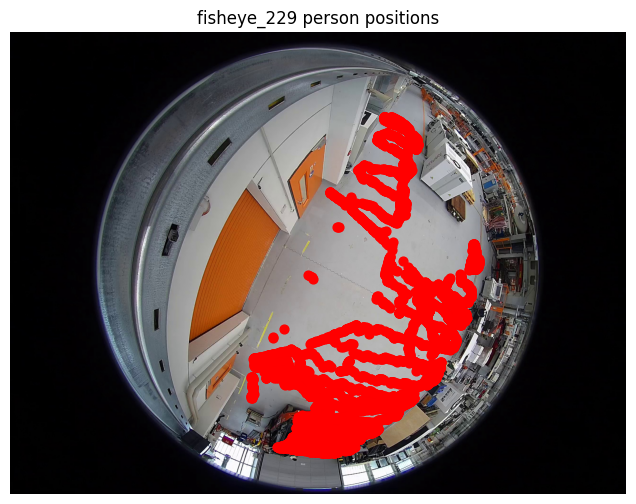

In [45]:
img_229 = cv2.cvtColor(cv2.imread("capture_15/fisheye_1_229.jpg"), cv2.COLOR_BGR2RGB)
width, height = 2592, 1944
positions_229 = np.array(
    [d["position"] for d in fisheye_229_data_person],
    dtype=np.float32
)
plt.figure(figsize=(8, 6))
plt.imshow(img_229)

plt.scatter(
    positions_229[:, 0],
    positions_229[:, 1],
    c="red",
    s=40
)

plt.title("fisheye_229 person positions")
plt.xlim(0, width)
plt.ylim(height, 0)  
plt.axis("off")
plt.show()

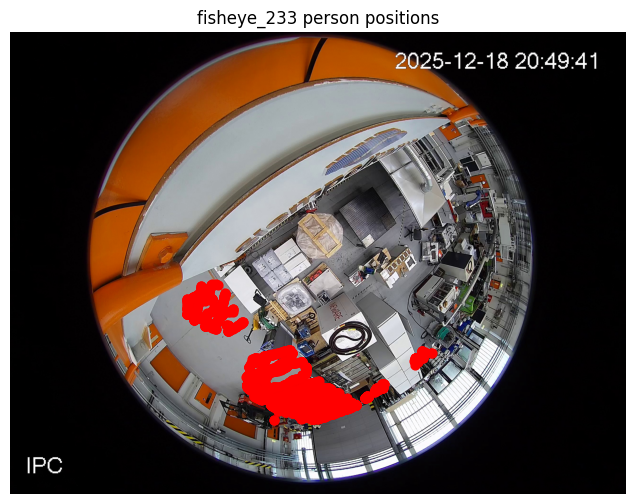

In [44]:

img_233 = cv2.cvtColor(cv2.imread("capture_15/fisheye_1_233.jpg"), cv2.COLOR_BGR2RGB)
width, height = 2592, 1944

positions_233 = np.array(
    [d["position"] for d in fisheye_233_data_person],
    dtype=np.float32
)
plt.figure(figsize=(8, 6))
plt.imshow(img_233)

plt.scatter(
    positions_233[:, 0],
    positions_233[:, 1],
    c="red",
    s=40
)

plt.title("fisheye_233 person positions")
plt.xlim(0, width)
plt.ylim(height, 0)  
plt.axis("off")
plt.show()


In [22]:
fisheye_229_common = []
fisheye_233_common = []
map_233 = {
    d["kafka_timestamp_ms"]: d
    for d in fisheye_233_data_person
}
for camera_229 in fisheye_229_data_person:
    ts = camera_229["kafka_timestamp_ms"]

    if ts in map_233:
        fisheye_229_common.append(camera_229)
        fisheye_233_common.append(map_233[ts])

In [33]:
fisheye_229_common

[{'camera': 'fisheye_229',
  'frame_id': '78',
  'position': [1860.22607421875, 1227.708251953125],
  'camera_timestamp': '2025-12-22 12:15:07.784',
  'kafka_timestamp_ms': 1766405707784},
 {'camera': 'fisheye_229',
  'frame_id': '821',
  'position': [1494.5440673828125, 1587.7191162109375],
  'camera_timestamp': '2025-12-22 12:15:39.596',
  'kafka_timestamp_ms': 1766405739596},
 {'camera': 'fisheye_229',
  'frame_id': '858',
  'position': [1308.374755859375, 1645.012939453125],
  'camera_timestamp': '2025-12-22 12:15:41.057',
  'kafka_timestamp_ms': 1766405741057},
 {'camera': 'fisheye_229',
  'frame_id': '878',
  'position': [1249.4808349609375, 1654.8265380859375],
  'camera_timestamp': '2025-12-22 12:15:41.851',
  'kafka_timestamp_ms': 1766405741851},
 {'camera': 'fisheye_229',
  'frame_id': '880',
  'position': [1232.647216796875, 1660.107666015625],
  'camera_timestamp': '2025-12-22 12:15:41.927',
  'kafka_timestamp_ms': 1766405741927},
 {'camera': 'fisheye_229',
  'frame_id': '2

In [23]:
print(len(fisheye_229_common))
print(len(fisheye_233_common))

54
54


In [29]:
pts_229 = np.array(
    [d["position"] for d in fisheye_229_common],
    dtype=np.float32
)

pts_233 = np.array(
    [d["position"] for d in fisheye_233_common],
    dtype=np.float32
)

hull_229_idx = set(
    cv2.convexHull(pts_229, returnPoints=False).squeeze().tolist()
)

hull_233_idx = set(
    cv2.convexHull(pts_233, returnPoints=False).squeeze().tolist()
)

common_idx = sorted(hull_229_idx & hull_233_idx)
print("Final polygon points:", len(common_idx))

pts_229_final = pts_229[common_idx]
pts_233_final = pts_233[common_idx]

def ccw_order_indices(pts):
    center = np.mean(pts, axis=0)
    angles = np.arctan2(
        pts[:, 1] - center[1],
        pts[:, 0] - center[0]
    )
    return np.argsort(angles)

order = ccw_order_indices(pts_229_final)

pts_229_final = pts_229_final[order]
pts_233_final = pts_233_final[order]

assert pts_229_final.shape == pts_233_final.shape
assert pts_229_final.shape[0] >= 4



Final polygon points: 6


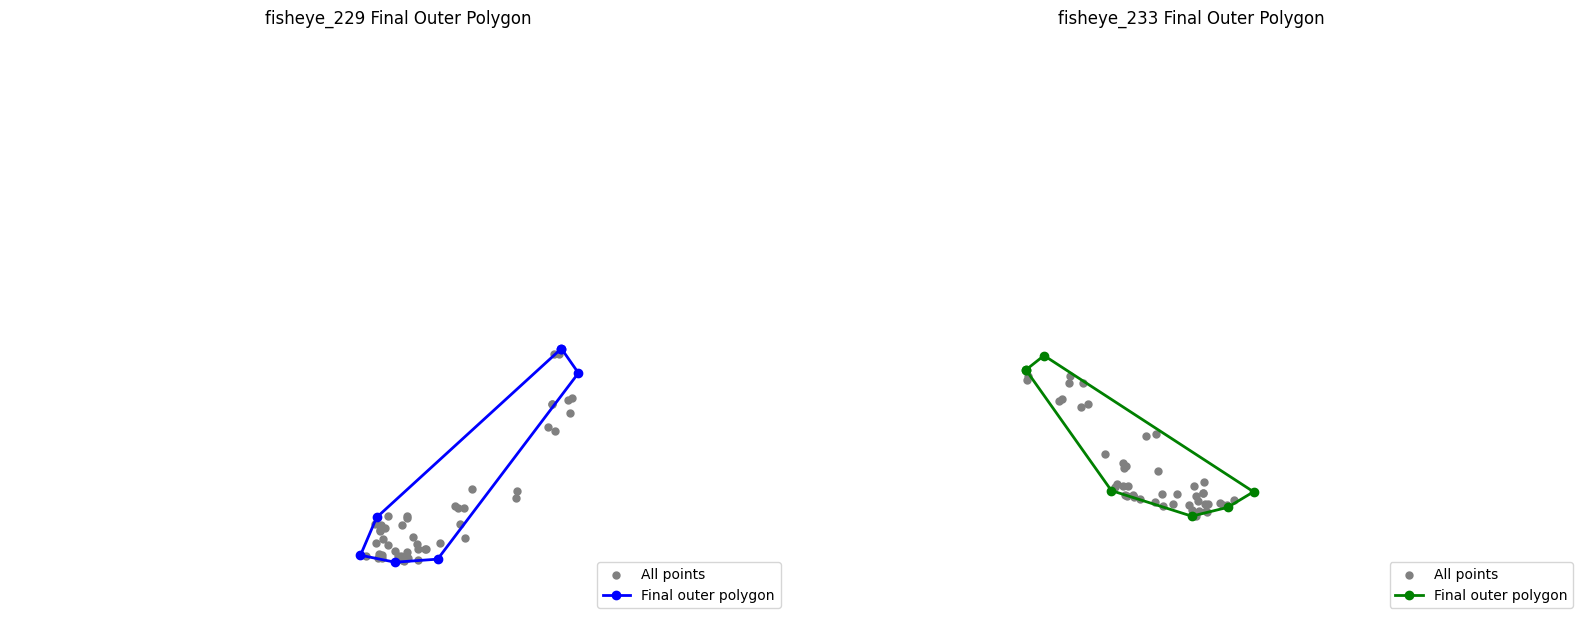

In [30]:

width, height = 2592, 1944
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
axs[0].imshow(np.ones((height, width, 3)))
axs[0].scatter(
    pts_229[:, 0], pts_229[:, 1],
    c="gray", s=25, label="All points"
)

closed_229 = np.vstack([pts_229_final, pts_229_final[0]])
axs[0].plot(
    closed_229[:, 0], closed_229[:, 1],
    "-o", color="blue", linewidth=2, label="Final outer polygon"
)

axs[0].set_title("fisheye_229 Final Outer Polygon")
axs[0].set_xlim(0, width)
axs[0].set_ylim(height, 0)
axs[0].axis("off")
axs[0].legend(loc="lower right")
axs[1].imshow(np.ones((height, width, 3)))
axs[1].scatter(
    pts_233[:, 0], pts_233[:, 1],
    c="gray", s=25, label="All points"
)

closed_233 = np.vstack([pts_233_final, pts_233_final[0]])
axs[1].plot(
    closed_233[:, 0], closed_233[:, 1],
    "-o", color="green", linewidth=2, label="Final outer polygon"
)

axs[1].set_title("fisheye_233 Final Outer Polygon")
axs[1].set_xlim(0, width)
axs[1].set_ylim(height, 0)
axs[1].axis("off")
axs[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


In [26]:
pts_229_final

array([[1838.2345, 1055.7816],
       [1894.9556, 1137.3135],
       [1425.7051, 1757.7894],
       [1283.6074, 1768.0696],
       [1168.4015, 1744.7393],
       [1222.2643, 1618.7266]], dtype=float32)

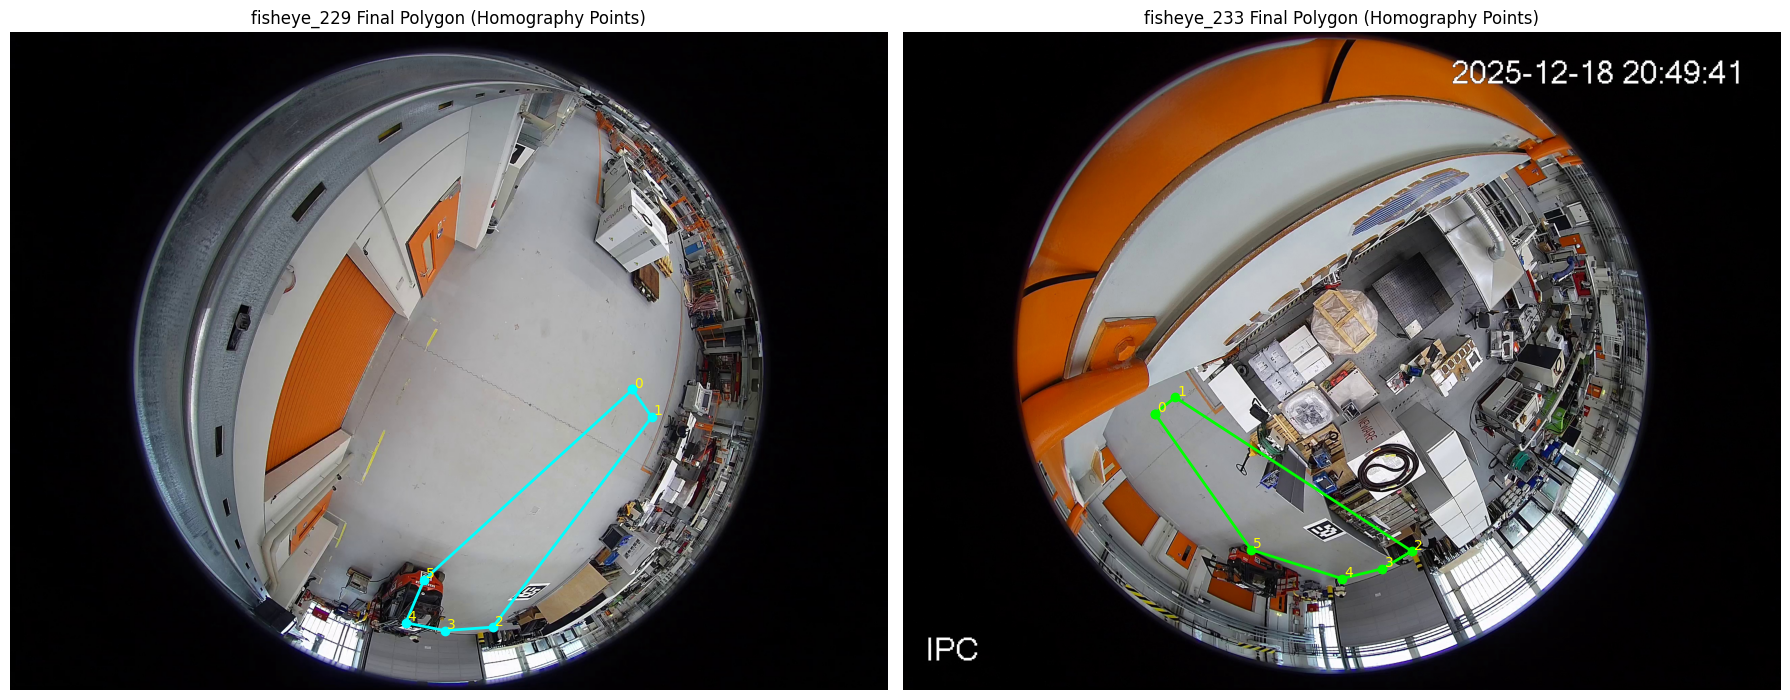

In [ ]:

img_229 = cv2.cvtColor(cv2.imread("capture_15/fisheye_1_229.jpg"), cv2.COLOR_BGR2RGB)
img_233 = cv2.cvtColor(cv2.imread("capture_15/fisheye_1_233.jpg"), cv2.COLOR_BGR2RGB)


def plot_polygon_on_image(ax, img, pts, title, color):
    ax.imshow(img)
    closed = np.vstack([pts, pts[0]])
    ax.plot(
        closed[:, 0],
        closed[:, 1],
        "-o",
        color=color,
        linewidth=2,
        markersize=6
    )

    for i, (x, y) in enumerate(pts):
        ax.text(x + 6, y - 6, str(i), color="yellow", fontsize=10)

    ax.set_title(title)
    ax.axis("off")


fig, axs = plt.subplots(1, 2, figsize=(18, 8))

plot_polygon_on_image(
    axs[0],
    img_229,
    pts_229_final,
    "fisheye_229 Final Polygon (Homography Points)",
    color="cyan"
)

plot_polygon_on_image(
    axs[1],
    img_233,
    pts_233_final,
    "fisheye_233 Final Polygon (Homography Points)",
    color="lime"
)

plt.tight_layout()
plt.show()


In [46]:
TOL_MS = 20  # ±10 ms tolerance

fisheye_229_sorted = sorted(
    fisheye_229_data_person,
    key=lambda x: x["kafka_timestamp_ms"]
)

fisheye_233_sorted = sorted(
    fisheye_233_data_person,
    key=lambda x: x["kafka_timestamp_ms"]
)

fisheye_229_common = []
fisheye_233_common = []

i, j = 0, 0

while i < len(fisheye_229_sorted) and j < len(fisheye_233_sorted):
    ts_229 = fisheye_229_sorted[i]["kafka_timestamp_ms"]
    ts_233 = fisheye_233_sorted[j]["kafka_timestamp_ms"]

    diff = ts_229 - ts_233

    if abs(diff) <= TOL_MS:
        fisheye_229_common.append(fisheye_229_sorted[i])
        fisheye_233_common.append(fisheye_233_sorted[j])
        i += 1
        j += 1

    elif diff < -TOL_MS:
        i += 1
    else:
        j += 1

print("Matched pairs:", len(fisheye_229_common))

pts_229 = np.array(
    [d["position"] for d in fisheye_229_common],
    dtype=np.float32
)

pts_233 = np.array(
    [d["position"] for d in fisheye_233_common],
    dtype=np.float32
)

hull_229_idx = set(
    cv2.convexHull(pts_229, returnPoints=False).squeeze().tolist()
)

hull_233_idx = set(
    cv2.convexHull(pts_233, returnPoints=False).squeeze().tolist()
)

# --------------------------------------------------
# 5) KEEP ONLY POINTS ON HULL IN BOTH CAMERAS
# --------------------------------------------------
common_idx = sorted(hull_229_idx & hull_233_idx)
print("Final polygon points:", len(common_idx))

pts_229_final = pts_229[common_idx]
pts_233_final = pts_233[common_idx]

# --------------------------------------------------
# 6) COMPUTE ONE CCW ORDER (USING fisheye_229)
#    AND APPLY TO BOTH
# --------------------------------------------------
def ccw_order_indices(pts):
    center = pts.mean(axis=0)
    angles = np.arctan2(
        pts[:, 1] - center[1],
        pts[:, 0] - center[0]
    )
    return np.argsort(angles)

order = ccw_order_indices(pts_229_final)

pts_229_final = pts_229_final[order]
pts_233_final = pts_233_final[order]

# --------------------------------------------------
# 7) FINAL SANITY CHECKS
# --------------------------------------------------
assert pts_229_final.shape == pts_233_final.shape
assert pts_229_final.shape[0] >= 4

for i in range(len(pts_229_final)):
    ts_229 = fisheye_229_common[common_idx[order[i]]]["kafka_timestamp_ms"]
    ts_233 = fisheye_233_common[common_idx[order[i]]]["kafka_timestamp_ms"]
    assert abs(ts_229 - ts_233) <= TOL_MS

print("✅ Points are correctly matched, ordered, and homography-safe.")


Matched pairs: 1414
Final polygon points: 8
✅ Points are correctly matched, ordered, and homography-safe.


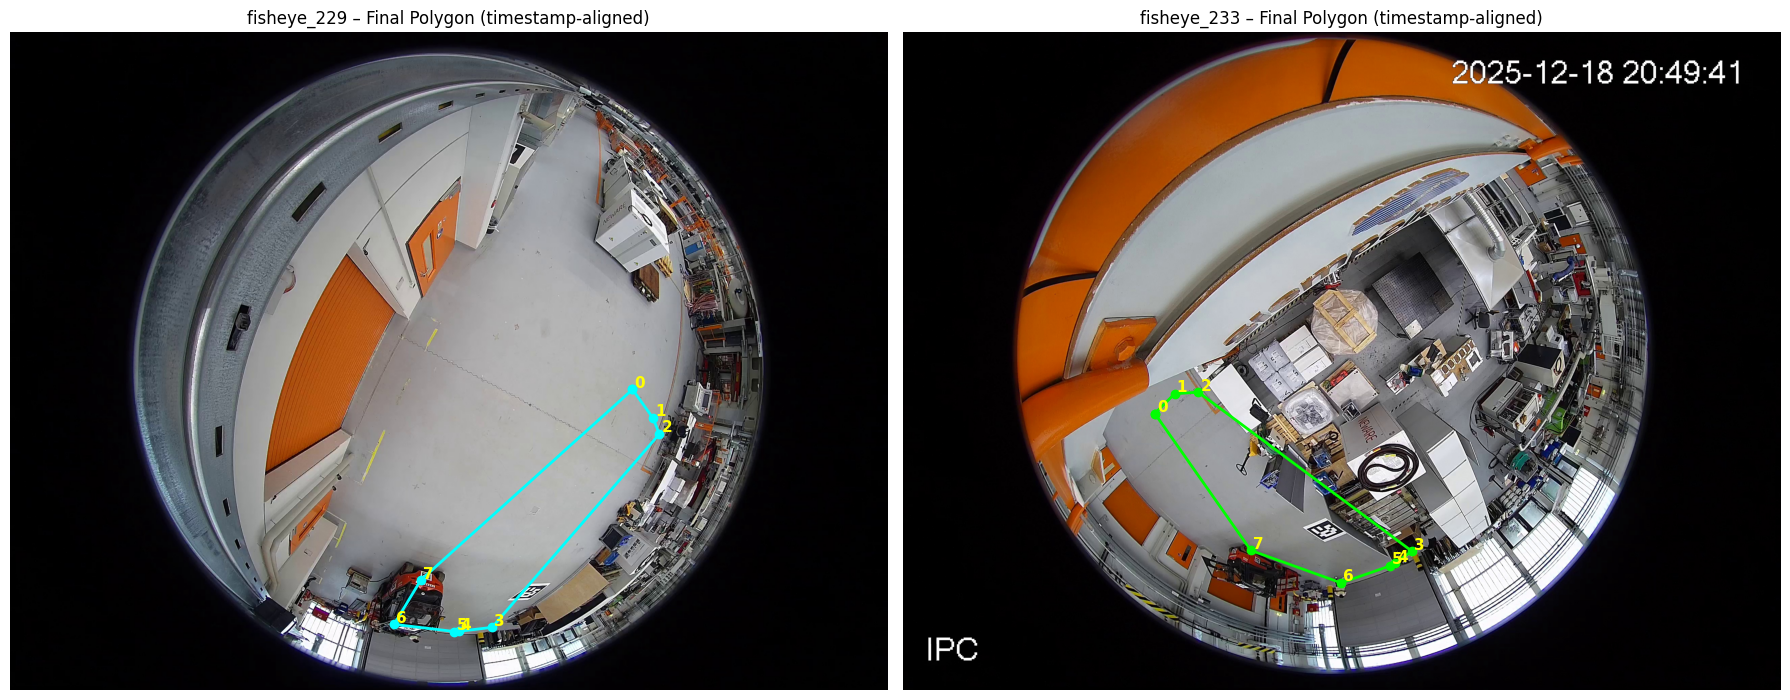

In [47]:


def draw_polygon(ax, img, pts, title, color):
    ax.imshow(img)

    # close polygon
    closed = np.vstack([pts, pts[0]])

    # draw polygon edges
    ax.plot(
        closed[:, 0],
        closed[:, 1],
        "-o",
        color=color,
        linewidth=2,
        markersize=6
    )

    # label points by index (CRITICAL for verification)
    for i, (x, y) in enumerate(pts):
        ax.text(
            x + 6,
            y - 6,
            str(i),
            color="yellow",
            fontsize=11,
            weight="bold"
        )

    ax.set_title(title)
    ax.axis("off")


fig, axs = plt.subplots(1, 2, figsize=(18, 8))

draw_polygon(
    axs[0],
    img_229,
    pts_229_final,
    "fisheye_229 – Final Polygon (timestamp-aligned)",
    color="cyan"
)

draw_polygon(
    axs[1],
    img_233,
    pts_233_final,
    "fisheye_233 – Final Polygon (timestamp-aligned)",
    color="lime"
)

plt.tight_layout()
plt.show()
